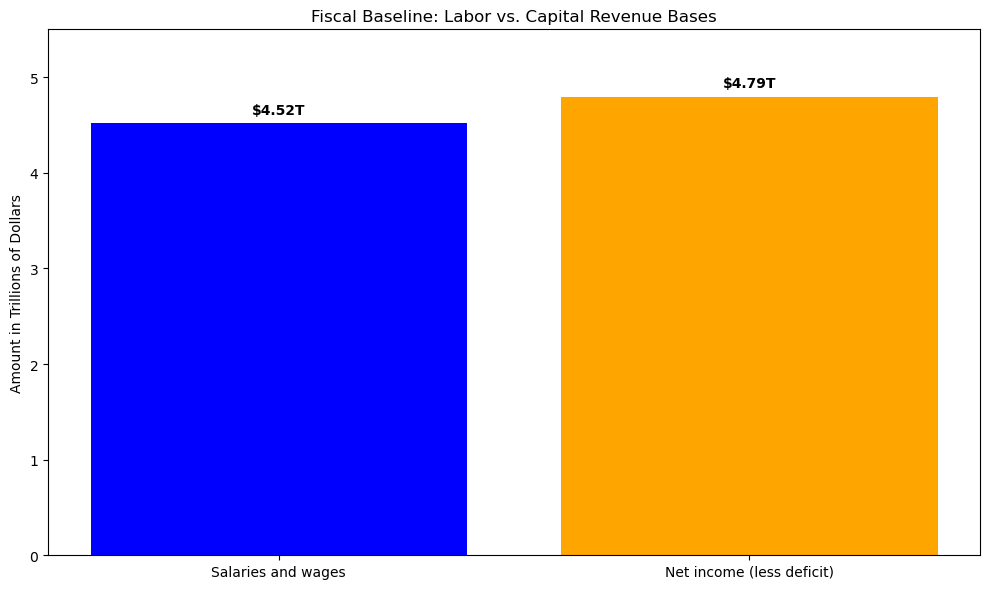

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load Data
file_path = 'Table_2.xlsx'
df = pd.read_excel(file_path, sheet_name='Table 2.1', skiprows=4)

# 2. Filter Rows
target_rows = ['Salaries and wages', 'Net income (less deficit)']
filtered_df = df[df.iloc[:, 0].isin(target_rows)].copy()

# 3. Data Cleaning & Conversion
# Convert 'Total' column (index 1) to numeric
filtered_df.iloc[:, 1] = pd.to_numeric(filtered_df.iloc[:, 1], errors='coerce')

# Convert from Thousands of Dollars to Trillions of Dollars
# Calculation: (Value * 1,000) / 1,000,000,000,000 = Value / 1,000,000,000
filtered_df.iloc[:, 1] = filtered_df.iloc[:, 1] / 1e9

# 4. Visualization
labels = filtered_df.iloc[:, 0].tolist()
values = filtered_df.iloc[:, 1].tolist()

plt.figure(figsize=(10, 6))
plt.bar(labels, values, color=['blue', 'orange'])

# Formatting
plt.title('Fiscal Baseline: Labor vs. Capital Revenue Bases')
plt.ylabel('Amount in Trillions of Dollars')
plt.ylim(0, 5.5) # Set limit for better perspective

# Add value labels on top of bars
for i, v in enumerate(values):
    plt.text(i, v + 0.1, f'${v:.2f}T', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()